In [16]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

In [22]:
print(os.getcwd())

/Users/sophie/Seaglider/SeagliderData/cleaned data


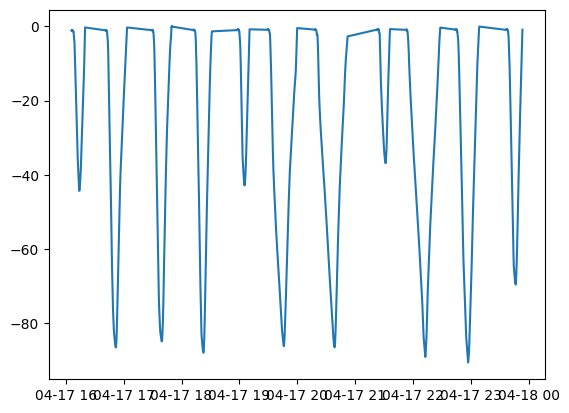

In [23]:
times_ds = xr.open_dataset('sg194_2025_04_17_Edmonds_timeseries.nc')
times_ds.time.values[0]

time = times_ds.time.values
depth = times_ds.depth.values
plt.plot(time, -depth)

In [19]:
times_ds.time.values[0]

np.datetime64('2026-04-17T16:06:00.790999808')

In [20]:
display(times_ds)

<xarray.Dataset> Size: 351kB
Dimensions:                                   (gps_info: 33,
                                               sg_data_point: 1876,
                                               trajectory: 11, dive: 11)
Coordinates:
    ctd_time                                  (sg_data_point) datetime64[ns] 15kB ...
    ctd_depth                                 (sg_data_point) float32 8kB ...
    latitude                                  (sg_data_point) float32 8kB ...
    longitude                                 (sg_data_point) float32 8kB ...
  * trajectory                                (trajectory) int32 44B 3 4 ... 13
Dimensions without coordinates: gps_info, sg_data_point, dive
Data variables: (12/67)
    gps_info_dive_number                      (gps_info) int32 132B ...
    sg_data_point_dive_number                 (sg_data_point) int32 8kB ...
    log_gps_time                              (gps_info) datetime64[ns] 264B ...
    time                                      (sg_data_point) datetime64[ns] 15kB ...
    pressure                                  (sg_data_point) float32 8kB ...
    depth                                     (sg_data_point) float32 8kB 1.1...
    ...                                        ...
    end_longitude                             (dive) float32 44B ...
    depth_avg_curr_east                       (dive) float32 44B ...
    depth_avg_curr_north                      (dive) float32 44B ...
    depth_avg_curr_qc                         (dive) |S1 11B ...
    latlong_qc                                (dive) |S1 11B ...
    glider                                    |S12 12B ...
Attributes: (12/47)
    project:                         2025 04 17 Edmonds
    title:                           Physical, chemical, and biological data ...
    summary:                         SG194 2025 04 17 Edmonds
    source:                          Seaglider SG194
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2026-04-20T18:04:20Z
    uuid:                            5ce68302-3ce9-11f1-9ea1-774cb83f18cf
    base_station_version:            3.0.6
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6

In [24]:
print(os.getcwd())
#Load the dataset

#Align time with sg_data_point and apply offset (if needed)
adjusted_time = pd.to_datetime(times_ds['time'].values) + pd.DateOffset(years=19, months=7, days=16)

times_ds['PAR_470nm'] = times_ds['eng_wlbb2fl_sig470nm']
times_ds['particle_concentration_700nm'] = times_ds['eng_wlbb2fl_sig700nm']
times_ds['chlorophyll_695nm'] = times_ds['eng_wlbb2fl_sig695nm']
times_ds['dissolved_oxygen'] = times_ds['aanderaa4330_dissolved_oxygen']
times_ds['instrument_dissolved_oxygen'] = times_ds['aanderaa4330_instrument_dissolved_oxygen']

# add metadata
times_ds['PAR_470nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig470nm'
times_ds['particle_concentration_700nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig700nm'
times_ds['chlorophyll_695nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig695nm'
times_ds['dissolved_oxygen'].attrs['pre_cleaning_name'] = 'aanderaa4330_dissolved_oxygen'
times_ds['instrument_dissolved_oxygen'].attrs['pre_cleaning_name'] = 'aanderaa4330_instrument_dissolved_oxygen'

times_ds = times_ds.assign_coords(time=('sg_data_point', adjusted_time))

#Select the relevant variables
new_times_ds = times_ds[['time', 'depth', 'latitude', 'longitude','temperature', 'salinity', 'dissolved_oxygen', 'instrument_dissolved_oxygen', 'PAR_470nm', 'particle_concentration_700nm', 'chlorophyll_695nm']]

#Convert to DataFrame and save
new_times_ds.to_dataframe().reset_index().to_csv('sg194_Edmonds_timeseries_cleaned.csv', index=False)
new_times_ds.to_netcdf('sg194_Edmonds_timeseries_cleaned.nc')
display(new_times_ds)

/Users/sophie/Seaglider/SeagliderData/cleaned data


<xarray.Dataset> Size: 113kB
Dimensions:                       (sg_data_point: 1876)
Coordinates:
    time                          (sg_data_point) datetime64[ns] 15kB 2045-12...
    latitude                      (sg_data_point) float32 8kB 47.83 ... 47.82
    longitude                     (sg_data_point) float32 8kB -122.4 ... -122.4
    ctd_time                      (sg_data_point) datetime64[ns] 15kB 2026-04...
    ctd_depth                     (sg_data_point) float32 8kB 0.5147 ... 0.8802
Dimensions without coordinates: sg_data_point
Data variables:
    depth                         (sg_data_point) float32 8kB 1.108 ... 0.8883
    temperature                   (sg_data_point) float32 8kB 9.969 ... 10.09
    salinity                      (sg_data_point) float32 8kB nan nan ... nan
    dissolved_oxygen              (sg_data_point) float32 8kB nan nan ... nan
    instrument_dissolved_oxygen   (sg_data_point) float32 8kB nan nan ... nan
    PAR_470nm                     (sg_data_point) float32 8kB 572.0 ... 846.0
    particle_concentration_700nm  (sg_data_point) float32 8kB 135.0 ... 131.0
    chlorophyll_695nm             (sg_data_point) float32 8kB 532.0 ... 505.0
Attributes: (12/47)
    project:                         2025 04 17 Edmonds
    title:                           Physical, chemical, and biological data ...
    summary:                         SG194 2025 04 17 Edmonds
    source:                          Seaglider SG194
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2026-04-20T18:04:20Z
    uuid:                            5ce68302-3ce9-11f1-9ea1-774cb83f18cf
    base_station_version:            3.0.6
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6

In [25]:
pd.to_datetime(times_ds['time'].values[0])

Timestamp('2045-12-03 16:06:00.790999808')

In [26]:
#Apply time apply offset (if needed)
adjusted_time = pd.to_datetime(times_ds['time'].values) + pd.DateOffset(years=19, months=7, days=16)
times_ds['start_time'] = pd.to_datetime(times_ds['time'].values[0])
times_ds['end_time'] = pd.to_datetime(times_ds['time'].values[-1])

times_ds['U_DAC'] = times_ds['depth_avg_curr_east']
times_ds['V_DAC'] = times_ds['depth_avg_curr_north']

# add metadata
times_ds['U_DAC'].attrs['pre_cleaning_name'] = 'depth_avg_curr_east'
times_ds['V_DAC'].attrs['pre_cleaning_name'] = 'depth_avg_curr_north'

#Select the relevant variables
new_times_ds = times_ds[['U_DAC', 'V_DAC', 'start_time', 'end_time', 'start_latitude', 'end_latitude', 'start_longitude', 'end_longitude']]
display(new_times_ds)

#Convert to DataFrame and save
new_times_ds.to_dataframe().reset_index().to_csv('sg194_Edmonds_DAC_timeseries_cleaned.csv', index=False)
new_times_ds.to_netcdf('sg194_Edmonds_DAC_timeseries_cleaned.nc')


<xarray.Dataset> Size: 280B
Dimensions:          (dive: 11)
Dimensions without coordinates: dive
Data variables:
    U_DAC            (dive) float32 44B ...
    V_DAC            (dive) float32 44B ...
    start_time       datetime64[ns] 8B 2045-12-03T16:06:00.790999808
    end_time         datetime64[ns] 8B 2045-12-03T23:53:20.100000
    start_latitude   (dive) float32 44B ...
    end_latitude     (dive) float32 44B ...
    start_longitude  (dive) float32 44B ...
    end_longitude    (dive) float32 44B ...
Attributes: (12/47)
    project:                         2025 04 17 Edmonds
    title:                           Physical, chemical, and biological data ...
    summary:                         SG194 2025 04 17 Edmonds
    source:                          Seaglider SG194
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2026-04-20T18:04:20Z
    uuid:                            5ce68302-3ce9-11f1-9ea1-774cb83f18cf
    base_station_version:            3.0.6
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6